<a href="https://colab.research.google.com/github/Yashb404/MUJ-ML-Lab/blob/main/ML_Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             PrecisionRecallDisplay, RocCurveDisplay)

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target # 0 = malignant, 1 = benign

# Split the dataset into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the data (crucial for distance-based algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dataset loaded and preprocessed successfully!")

Dataset loaded and preprocessed successfully!


--- Experiment 1: K-Nearest Neighbour (KNN) ---
Accuracy: 0.9591

Confusion Matrix:
 [[ 59   4]
 [  3 105]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



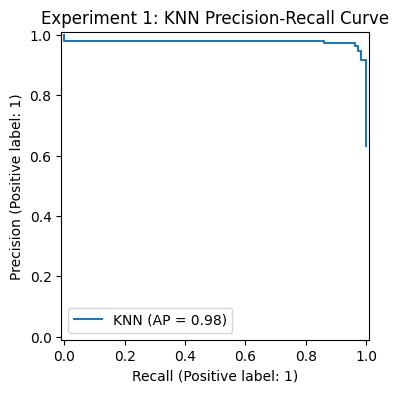

In [3]:
print("--- Experiment 1: K-Nearest Neighbour (KNN) ---")

# 1. Train the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# 2. Predict class labels for the test data
y_pred_knn = knn.predict(X_test_scaled)

# 3. Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

# 4. Precision-Recall Curve
fig, ax = plt.subplots(figsize=(6, 4))
PrecisionRecallDisplay.from_estimator(knn, X_test_scaled, y_test, ax=ax, name="KNN")
plt.title("Experiment 1: KNN Precision-Recall Curve")
plt.show()

--- Experiment 2: Support Vector Machine (SVM) ---
Accuracy: 0.9766

Confusion Matrix:
 [[ 61   2]
 [  2 106]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        63
           1       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



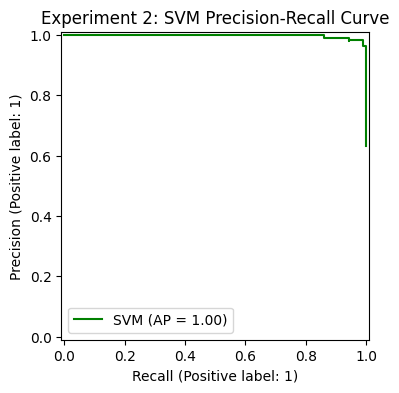

In [4]:
print("--- Experiment 2: Support Vector Machine (SVM) ---")

# 1. Train the SVM classifier
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 2. Predict class labels for the test data
y_pred_svm = svm_model.predict(X_test_scaled)

# 3. Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

# 4. Precision-Recall Curve
fig, ax = plt.subplots(figsize=(6, 4))
PrecisionRecallDisplay.from_estimator(svm_model, X_test_scaled, y_test, ax=ax, name="SVM", color="green")
plt.title("Experiment 2: SVM Precision-Recall Curve")
plt.show()

--- Experiment 3: Model Comparisons ---


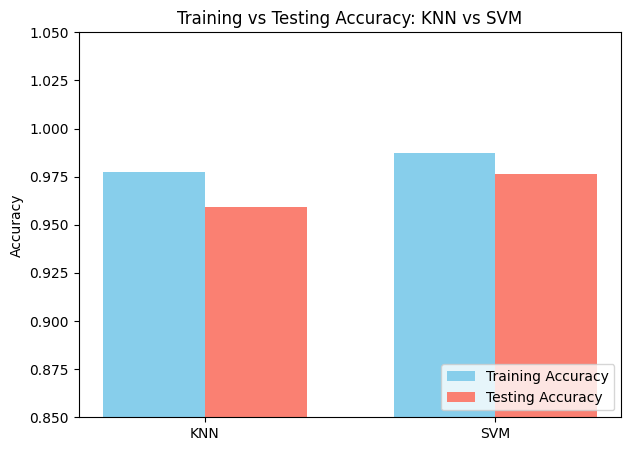

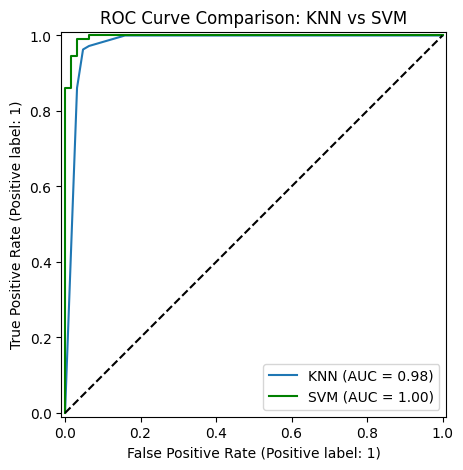

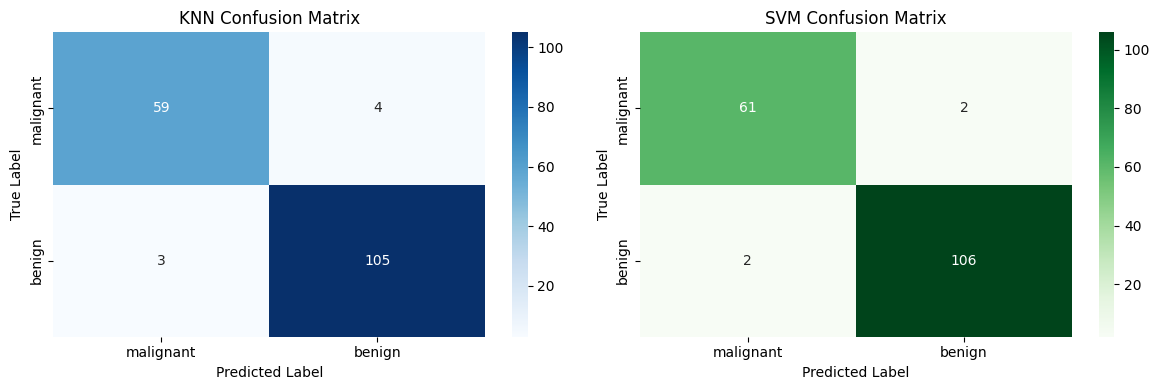

In [5]:
print("--- Experiment 3: Model Comparisons ---")

# 1. Bar chart comparing training and testing accuracy
models = ['KNN', 'SVM']
train_acc = [knn.score(X_train_scaled, y_train), svm_model.score(X_train_scaled, y_train)]
test_acc = [accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_svm)]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, train_acc, width, label='Training Accuracy', color='skyblue')
ax.bar(x + width/2, test_acc, width, label='Testing Accuracy', color='salmon')
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Testing Accuracy: KNN vs SVM')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='lower right')
plt.ylim(0.85, 1.05)
plt.show()

# 2. ROC curve comparison
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(knn, X_test_scaled, y_test, ax=ax, name='KNN')
RocCurveDisplay.from_estimator(svm_model, X_test_scaled, y_test, ax=ax, name='SVM', color='green')
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.title("ROC Curve Comparison: KNN vs SVM")
plt.show()

# 3. Confusion Matrix Heatmap (Side-by-Side)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=data.target_names, yticklabels=data.target_names)
axes[0].set_title('KNN Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=data.target_names, yticklabels=data.target_names)
axes[1].set_title('SVM Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()